In [1]:
from glob import glob
import time
import itertools
import pickle as pkl
from GenomicTools.tools import *
from GenomicTools.dot_plots import *
from GenomicTools.tandem_duplications import *
from GenomicTools.synteny import *
from GenomicTools.permutations import *

### Load the species data, create chromosome information dictionaries and TDEC shift maps

In [2]:
spA, species_data_A, labels, chrom_info_A = load_species_data('Homo_sapiens-species_data.csv.gz')
chrom_info_A = get_chrom_info(species_data_A)
maps_A = create_shift_map(species_data_A)

In [3]:
spB, species_data_B, labels, chrom_info_B = load_species_data('Mus_musculus-species_data.csv.gz')
chrom_info_B = get_chrom_info(species_data_B)
maps_B = create_shift_map(species_data_B)

### Load dot plot and condense into TDECs

In [6]:
spA, spB, dot_plot, labels = load_dot_plot('Homo_sapiens-Mus_musculus-homology_matrix.csv.gz')
condensed_dot_plot = shift_dots(dot_plot,species_data_A,species_data_B,maps_A,maps_B)

### Calculate the minimum nanosynteny size

In [7]:
rho, N_A, N_B = calculate_density(dot_plot, chrom_info_A, chrom_info_B)
alpha = .05
kmin = k_min(alpha,rho,N_A,N_B)

### Calculate nanosynteny

In [22]:
nanosynteny = find_nanosynteny(condensed_dot_plot,species_data_A,species_data_B,chrom_info_A,chrom_info_B,maps_A,maps_B,kmin)

### Calculate microsynteny

In [13]:
microsynteny = find_microsynteny(condensed_dot_plot,nanosynteny,chrom_info_A,chrom_info_B,kmin,30,kmin)

### Shift microsynteny back from TDECs to genes and convert to absolute gene indices

In [16]:
unshifted_microsynteny = unshift_synteny_blocks(microsynteny, maps_A, maps_B, kmin)
absolute_microsynteny = convert_synteny_relative_to_absolute_indices(unshifted_microsynteny,chrom_info_A,chrom_info_B)

### Create a human-mouse dotplot

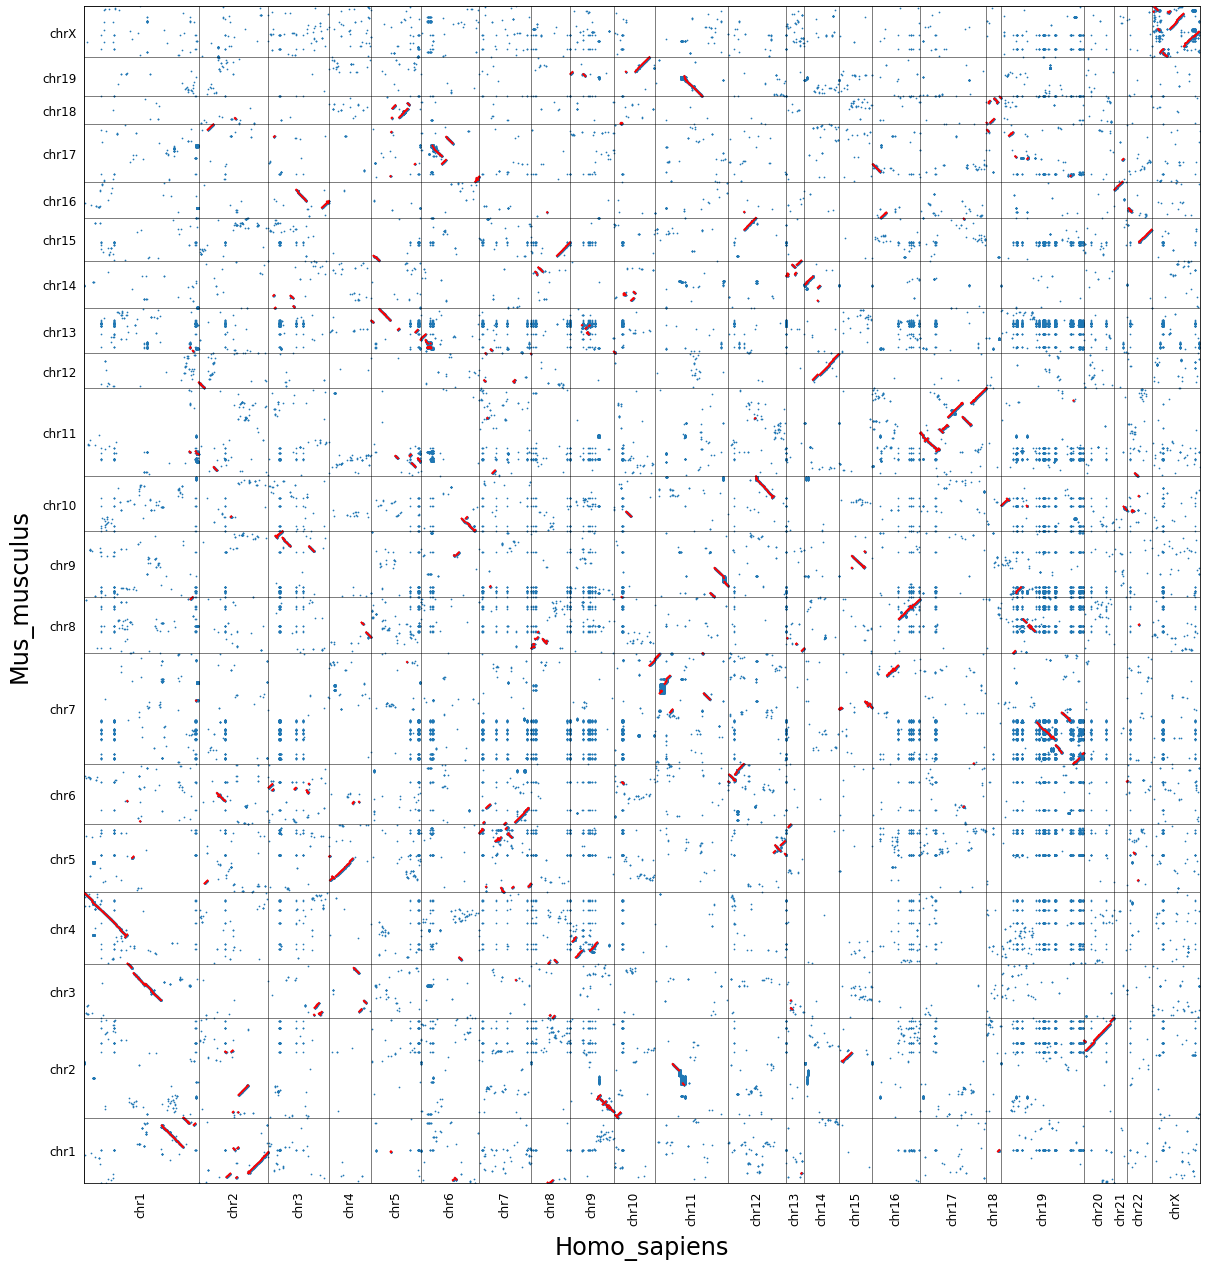

In [23]:
make_dot_plot_figure(dot_plot, chrom_info_A, chrom_info_B, synteny_blocks = absolute_microsynteny, label1 = spA, label2 = spB)